In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as fit

In [115]:
#1. CURVE FITTING GUIDED PROBLEM
#1.1
df = pd.read_csv('GlobalLandTemperaturesByState.csv')

df = df[['dt', 'AverageTemperature', 'State']]

df['dt'] = pd.to_datetime(df['dt'])
df = df[df['dt'].dt.year > 2000]

chosenstates = ['Wyoming', 'Nebraska', 'South Dakota']
df = df[df['State'].isin(chosenstates)]

df

,dt,AverageTemperature,State
350773,2001-01-01,-2.592,Nebraska
350774,2001-02-01,-5.575,Nebraska
350775,2001-03-01,2.077,Nebraska
350776,2001-04-01,10.431,Nebraska
350777,2001-05-01,15.878,Nebraska
...,...,...,...
626435,2013-05-01,10.607,Wyoming
626436,2013-06-01,16.267,Wyoming
626437,2013-07-01,20.222,Wyoming
626438,2013-08-01,19.621,Wyoming


In [117]:
#1.2
avg_temp_per_date = df.groupby('dt')['AverageTemperature'].mean().reset_index()
avg_temp_per_date.columns = ['Date', "AverageTemperature"]

avg_temp_per_date.head()

,Date,AverageTemperature
0,2001-01-01,-4.480333
1,2001-02-01,-7.541000
2,2001-03-01,0.590333
3,2001-04-01,7.889000
4,2001-05-01,13.908667


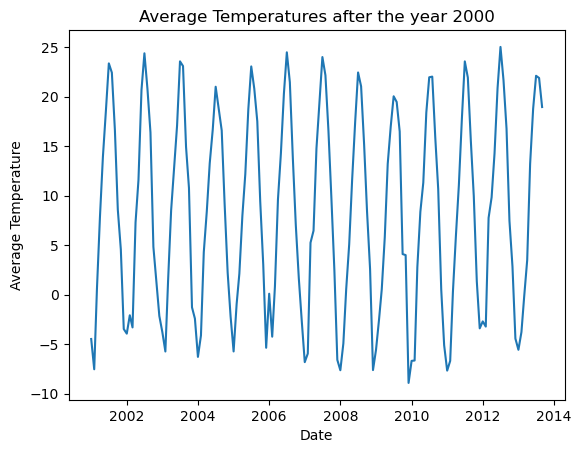

In [119]:
#1.3
plt.figure()
plt.plot(avg_temp_per_date['Date'], avg_temp_per_date['AverageTemperature'])

plt.xlabel('Date')
plt.ylabel('Average Temperature')
plt.title('Average Temperatures after the year 2000')

plt.show()

In [121]:
#1.4
avg_temp_per_date['Date'] = pd.to_datetime(avg_temp_per_date['Date'])
avg_temp_per_date['NumericDate'] = avg_temp_per_date['Date'].apply(lambda x: x.toordinal())
avg_temp_per_date

,Date,AverageTemperature,NumericDate
0,2001-01-01,-4.480333,730486
1,2001-02-01,-7.541000,730517
2,2001-03-01,0.590333,730545
3,2001-04-01,7.889000,730576
4,2001-05-01,13.908667,730606
...,...,...,...
148,2013-05-01,13.196000,734989
149,2013-06-01,18.783667,735020
150,2013-07-01,22.110333,735050
151,2013-08-01,21.890000,735081


In [123]:
#1.5
#T(x) = A*cos(Bx+C)+D
def temp_model(x, A, B, C, D):
    return A * np.cos(B * x + C) + D
prediction = [10, 2 * np.pi/365, 0, 8]

In [169]:
#1.6
x_data = avg_temp_per_date['NumericDate'].values
y_data = avg_temp_per_date['AverageTemperature'].values
params, cov = fit.curve_fit(temp_model, x_data, y_data, p0 = prediction)
params

array([13.89834072,  0.0172016 , 10.2210051 ,  8.17492361])

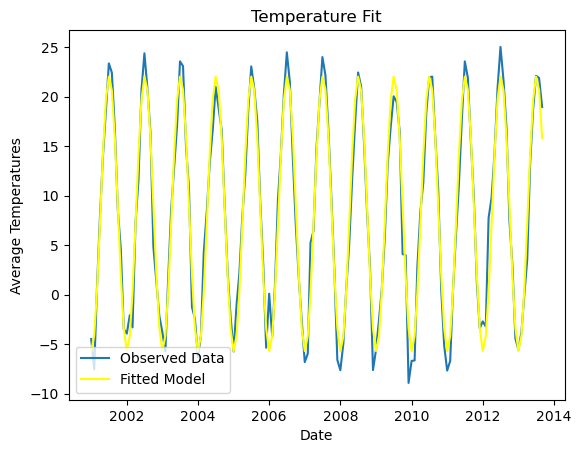

In [171]:
#1.7
plt.figure()
plt.plot(avg_temp_per_date['Date'], y_data, label='Observed Data')
plt.plot(avg_temp_per_date['Date'], temp_model(x_data, *params), label='Fitted Model', color = 'yellow')

plt.xlabel('Date')
plt.ylabel('Average Temperatures')
plt.title('Temperature Fit')
plt.legend()

plt.show()

In [173]:
#1.8
param_errors = np.sqrt(np.diag(cov))
param_names = ['A (Amplitude)', 'B (Frequency)', 'C (Phase Shift)', 'D (Offset)']
for name, value, error in zip(param_names, params, param_errors):
    print(f'{name}: {value:.4f} +_ {error:.4f}')

A (Amplitude): 13.8983 +_ 0.2268
B (Frequency): 0.0172 +_ 0.0000
C (Phase Shift): 10.2210 +_ 9.0053
D (Offset): 8.1749 +_ 0.1607


In [ ]:
#1.9
A, B, C, D = params
print(f"T(x) = {A:.4f} * cos({B:.6f} * x + {C:.4f}) + {D:.4f}")

In [220]:
#1.10.1
from astropy.table import Table

table = Table.read('global_CCl4_MM.dat', format='ascii')
table.colnames

['CCl4ottoyr',
 'CCl4ottomon',
 'CCl4ottoNHm',
 'CCl4ottoNHsd',
 'CCl4ottoSHm',
 'CCl4ottoSHsd',
 'CCl4ottoGLm',
 'CCl4ottoGLsd']

In [246]:
#1.10.2
df = table.to_pandas()
df = df.rename(columns={
    'CCl4ottoyr': 'date',                            
    'CCl4ottoGLm' : 'global mean concentration',       
    'CCl4ottoGLsd': 'global mean concentration sd' })
df = df[['date', 'global mean concentration', 'global mean concentration sd']]
df.columns = ['date', 'global_mean_conc', 'global_std_dev']


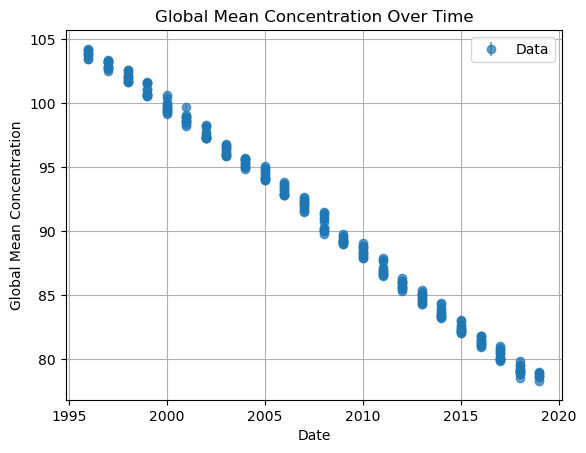

In [250]:
plt.errorbar(df['date'], df['global_mean_conc'], yerr=df['global_std_dev'], fmt='o', label='Data', ecolor='gray', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Global Mean Concentration')
plt.title('Global Mean Concentration Over Time')
plt.grid(True)
plt.legend()
plt.show()

In [260]:
#1.10.4
df = df.dropna()
def linear_model(x, a, b):
    return a * x + b

popt, pcov = fit.curve_fit(linear_model, df['date'], df['global_mean_conc'], sigma=df['global_std_dev'], absolute_sigma=True)
a, b = popt
a_err, b_err = np.sqrt(np.diag(pcov))


In [264]:
#1.10.5
residuals = df['global_mean_conc'] - linear_model(df['date'], *popt)
chi2 = np.sum((residuals / df['global_std_dev'])**2)
dof = len(df) - 2  # 2 parameters: a, b
reduced_chi2 = chi2 / dof

In [266]:
#1.10.6
print(f"Fitted linear model: y = {a:.4f}x + {b:.4f}")
print(f"Slope (a) = {a:.4f} ± {a_err:.4f}")
print(f"Intercept (b) = {b:.4f} ± {b_err:.4f}")
print(f"Reduced chi-squared = {reduced_chi2:.4f}")

Fitted linear model: y = -1.1520x + 2403.7901
Slope (a) = -1.1520 ± 0.0013
Intercept (b) = 2403.7901 ± 2.5696
Reduced chi-squared = 13.1873


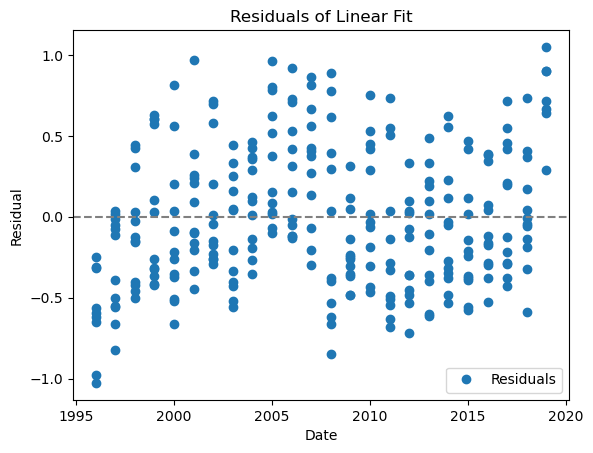

In [268]:
#1.10.7
plt.figure()
plt.plot(df['date'], residuals, 'o', label='Residuals')
plt.axhline(0, color='gray', linestyle='--')

plt.xlabel('Date')
plt.ylabel('Residual')
plt.title('Residuals of Linear Fit')
plt.legend()

plt.show()